<a href="https://colab.research.google.com/github/AhmadKevin000/machineLearning/blob/main/Week07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum Modul 6 — Filter Spasial
### Low Pass Filter, High Pass Filter, Point Detection, Line Detection, Edge Detection

**Mata Kuliah:** Pengolahan Citra dan Visi Komputer
**Nama:** _(Ahmad Kevin Malik Zakaria)_
**NIM:** _(244107020125)_


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0. Mount Google Drive & Import Library

Setiap gambar (`lena.jpg`, `djawatan.jpg`) akan dicari di Google Drive. Kalau tidak ditemukan, notebook otomatis meminta upload lewat `files.upload()` sehingga tetap jalan di Colab.

In [4]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception as e:
    print("Bukan di Colab / Drive tidak di-mount ->", e)
    IN_COLAB = False

import os
import math
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

%matplotlib inline
print("OpenCV :", cv.__version__)
print("NumPy  :", np.__version__)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
OpenCV : 4.14.0
NumPy  : 2.1.3


### Memuat gambar

Ubah `IMG_DIR` sesuai lokasi folder gambar di Drive-mu. Jika gambar tidak ada di Drive, akan muncul tombol upload.

In [5]:
def load_image(candidates, label):
    """Cari gambar di beberapa lokasi; kalau tidak ada, minta upload (Colab)."""
    for p in candidates:
        if p and os.path.exists(p):
            img = cv.imread(p)
            if img is not None:
                print(f"[{label}] terbaca dari: {p}  shape={img.shape}")
                return img
    try:
        from google.colab import files
        print(f"[{label}] tidak ditemukan. Silakan upload file '{label}'.")
        uploaded = files.upload()
        for name in uploaded:
            img = cv.imread(name)
            if img is not None:
                print(f"[{label}] terbaca dari: {name}  shape={img.shape}")
                return img
    except Exception as e:
        print("Upload tidak tersedia ->", e)
    raise FileNotFoundError(f"Gambar '{label}' tidak ditemukan.")

IMG_DIR = "/content/drive/MyDrive/Matkul Sem 5/PCVK/Images"

lena = load_image([
    os.path.join(IMG_DIR, "lena.jpg"),
    "/content/lena.jpg", "lena.jpg",
], "lena.jpg")

scene = load_image([
    os.path.join(IMG_DIR, "djawatan.jpg"),
    "/content/djawatan.jpg", "djawatan.jpg",
], "djawatan.jpg")

[lena.jpg] terbaca dari: /content/drive/MyDrive/Matkul Sem 5/PCVK/Images/lena.jpg  shape=(512, 512, 3)
[djawatan.jpg] terbaca dari: /content/drive/MyDrive/Matkul Sem 5/PCVK/Images/djawatan.jpg  shape=(720, 1080, 3)


In [6]:
def to_uint8(img):
    """Normalisasi hasil konvolusi (bisa negatif / >255) ke rentang 0-255 agar bisa ditampilkan."""
    out = img.astype(np.float64)
    out = out - out.min()
    if out.max() > 0:
        out = out / out.max() * 255.0
    return out.astype(np.uint8)

def show(img, title="", figsize=(5, 5)):
    plt.figure(figsize=figsize)
    if img.ndim == 2:
        plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    else:
        plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(title); plt.axis("off"); plt.show()

def show_side_by_side(images, titles, figsize=(15, 5)):
    """Tampilkan beberapa gambar berdampingan (dipakai di Bagian E)."""
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        if img.ndim == 2:
            plt.imshow(img, cmap="gray", vmin=0, vmax=255)
        else:
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title); plt.axis("off")
    plt.show()

---
# D. PRAKTIKUM FILTER

## 1. Fungsi Konvolusi (Manual, tanpa library)

Konvolusi 2D: setiap posisi kernel digeser pada citra, lalu dihitung penjumlahan perkalian titik:

$$g(x,y) = \sum_{k1}\sum_{k2} H(k1,k2) \cdot I(x+k1,\;y+k2)$$

Masalah piksel tepi ("menggantung") diselesaikan dengan **zero padding**.

In [7]:
def convolution2d_pseudocode(image, kernel):
    """Versi paling polos, persis mengikuti pseudocode Modul Bagian C.2 (tanpa padding).

    for x ... for y ... z = sum H(k1,k2) * Img(x+k1, y+k2)
    """
    img = image.astype(np.float64)
    k = kernel.astype(np.float64)
    kh, kw = k.shape
    H, W = img.shape
    out = np.zeros((H - kh + 1, W - kw + 1), dtype=np.float64)
    for x in range(out.shape[0]):
        for y in range(out.shape[1]):
            z = 0.0
            for k1 in range(kh):
                for k2 in range(kw):
                    z += k[k1, k2] * img[x + k1, y + k2]
            out[x, y] = z
    return out

f = np.array([[4, 4, 3, 5, 4],
              [6, 6, 5, 5, 2],
              [5, 6, 6, 6, 2],
              [6, 7, 5, 5, 3],
              [3, 5, 2, 4, 4]], dtype=np.float64)

h = np.array([[ 0, -1,  0],
              [-1,  4, -1],
              [ 0, -1,  0]], dtype=np.float64)

print("Citra input 5x5:\n", f)
print("\nHasil konvolusi (kernel di atas):\n", convolution2d_pseudocode(f, h))

Citra input 5x5:
 [[4. 4. 3. 5. 4.]
 [6. 6. 5. 5. 2.]
 [5. 6. 6. 6. 2.]
 [6. 7. 5. 5. 3.]
 [3. 5. 2. 4. 4.]]

Hasil konvolusi (kernel di atas):
 [[3. 0. 2.]
 [0. 2. 6.]
 [6. 0. 2.]]


### Fungsi konvolusi utama (dengan `stride` dan `padding`)

Parameter mengikuti modul: **image, kernel, stride, padding**. Sudah mendukung citra grayscale maupun warna.

In [8]:
def convolution2d(image, kernel, stride=1, padding=0):
    """Konvolusi 2D manual TANPA cv2.filter2D / scipy.

    Parameter
    ---------
    image  : citra input, grayscale (H,W) atau warna (H,W,3)
    kernel : matriks filter 2D
    stride : besar pergeseran kernel tiap langkah
    padding: jumlah baris/kolom nol yang ditambahkan di tepi citra
    """
    img = image.astype(np.float64)
    k = kernel.astype(np.float64)
    kh, kw = k.shape

    # 1. Zero padding di tepi -> solusi efek "menggantung"
    if padding > 0:
        pad_width = [(padding, padding), (padding, padding)]
        if img.ndim == 3:
            pad_width.append((0, 0))
        img = np.pad(img, pad_width, mode="constant", constant_values=0)

    H, W = img.shape[:2]
    out_h = (H - kh) // stride + 1
    out_w = (W - kw) // stride + 1

    # 2. Wadah hasil
    if img.ndim == 3:
        out = np.zeros((out_h, out_w, img.shape[2]), dtype=np.float64)
    else:
        out = np.zeros((out_h, out_w), dtype=np.float64)

    # 3. Geser kernel ke seluruh posisi, jumlahkan perkalian titik
    for i in range(out_h):
        for j in range(out_w):
            r, c = i * stride, j * stride
            window = img[r:r + kh, c:c + kw]
            if img.ndim == 3:
                out[i, j] = np.sum(window * k[..., None], axis=(0, 1))
            else:
                out[i, j] = np.sum(window * k)
    return out

### 2d. Load citra dan ubah ke citra keabuan (grayscale)

Ukuran citra: (512, 512)


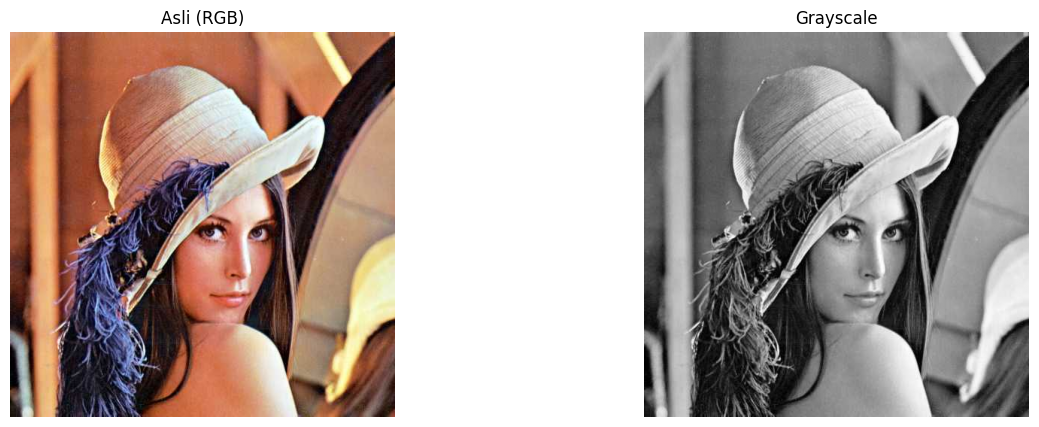

In [9]:
img = lena.copy()
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
print("Ukuran citra:", img_gray.shape)
show_side_by_side([img, img_gray], ["Asli (RGB)", "Grayscale"])

### 2e. Tentukan kernel (contoh: Sharpening)

In [10]:
kernel_sharpen = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]], dtype=np.float64)
print(kernel_sharpen)

[[ 0. -1.  0.]
 [-1.  5. -1.]
 [ 0. -1.  0.]]


### 2f. Panggil fungsi konvolusi dan tampilkan hasilnya

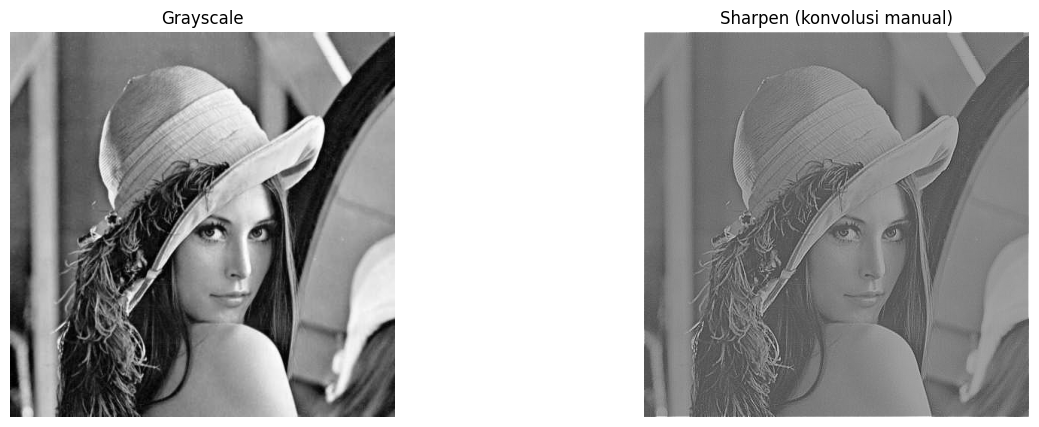

In [11]:
hasil_sharpen = convolution2d(img_gray, kernel_sharpen, stride=1, padding=1)
show_side_by_side([img_gray, to_uint8(hasil_sharpen)],
                  ["Grayscale", "Sharpen (konvolusi manual)"])

---
## 3. Image Filter: Average, Low Pass, High Pass, Sharpen, Emboss, Sobel, Laplacian, Point & Line Detection, Gaussian Blur

Semua kernel dari modul dikumpulkan di satu dictionary, lalu diterapkan memakai fungsi `convolution2d`.

In [12]:
kernels = {
    "Average 3x3":            np.ones((3, 3)) / 9.0,
    "Low Pass 3x3":           np.array([[1, 1, 1], [1, 4, 1], [1, 1, 1]], dtype=float) / 12.0,
    "High Pass 3x3":          np.array([[-1, 0, 1], [-1, 0, 3], [-3, 0, 1]], dtype=float),
    "Sharpen":                np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=float),
    "Emboss":                 np.array([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]], dtype=float),
    "Left Sobel Edge":        np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=float),
    "Laplacian (Canny-like)": np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]], dtype=float),
    "Point Detection":        np.array([[1, 1, 1], [1, -8, 1], [1, 1, 1]], dtype=float),
    "Line Horizontal":        np.array([[-1, -1, -1], [2, 2, 2], [-1, -1, -1]], dtype=float),
    "Line +45":               np.array([[2, -1, -1], [-1, 2, -1], [-1, -1, 2]], dtype=float),
    "Line Vertical":          np.array([[-1, 2, -1], [-1, 2, -1], [-1, 2, -1]], dtype=float),
    "Line -45":               np.array([[-1, -1, 2], [-1, 2, -1], [2, -1, -1]], dtype=float),
}

kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_1d = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_1d @ gaussian_1d.transpose()
kernels["Gaussian 21x21"] = gauss_kernel

print("Jumlah kernel:", len(kernels))
for name, k in kernels.items():
    print(f"  {name:24s} shape={k.shape}  sum={k.sum():.4f}")

Jumlah kernel: 13
  Average 3x3              shape=(3, 3)  sum=1.0000
  Low Pass 3x3             shape=(3, 3)  sum=1.0000
  High Pass 3x3            shape=(3, 3)  sum=0.0000
  Sharpen                  shape=(3, 3)  sum=1.0000
  Emboss                   shape=(3, 3)  sum=1.0000
  Left Sobel Edge          shape=(3, 3)  sum=0.0000
  Laplacian (Canny-like)   shape=(3, 3)  sum=0.0000
  Point Detection          shape=(3, 3)  sum=0.0000
  Line Horizontal          shape=(3, 3)  sum=0.0000
  Line +45                 shape=(3, 3)  sum=0.0000
  Line Vertical            shape=(3, 3)  sum=0.0000
  Line -45                 shape=(3, 3)  sum=0.0000
  Gaussian 21x21           shape=(21, 21)  sum=1.0000


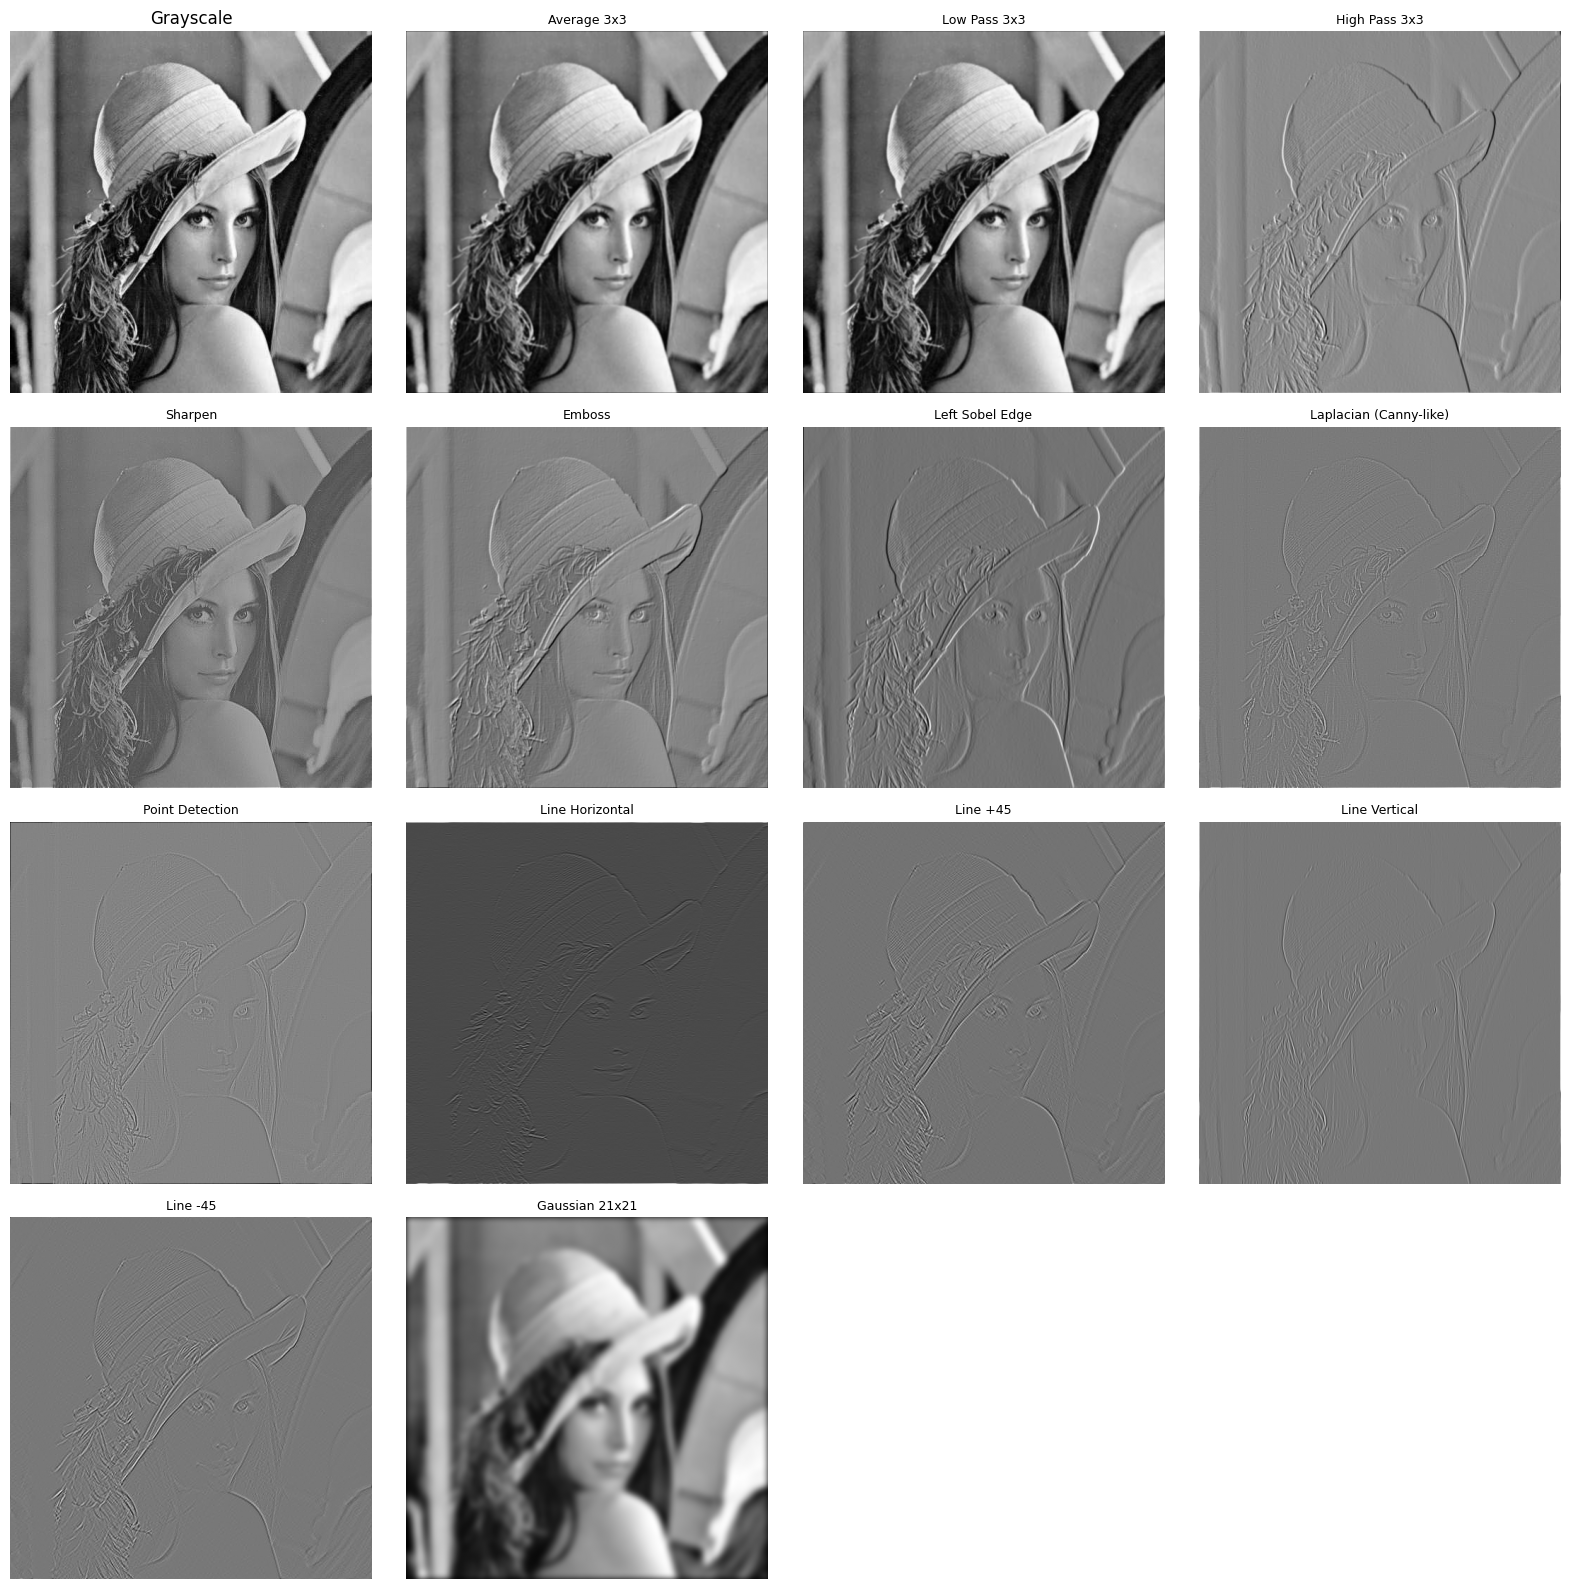

In [13]:
names = list(kernels.keys())
n = len(names)
cols = 4
rows = math.ceil((n + 1) / cols)

plt.figure(figsize=(4 * cols, 4 * rows))
plt.subplot(rows, cols, 1)
plt.imshow(img_gray, cmap="gray", vmin=0, vmax=255)
plt.title("Grayscale"); plt.axis("off")

for idx, (name, k) in enumerate(kernels.items()):
    res = convolution2d(img_gray, k, stride=1, padding=k.shape[0] // 2)
    plt.subplot(rows, cols, idx + 2)
    plt.imshow(to_uint8(res), cmap="gray")
    plt.title(name, fontsize=9); plt.axis("off")

plt.tight_layout()
plt.show()

---
# E. FILTER LIBRARY DAN FILTER MODERN

## Percobaan 1 — Gaussian, Sharpen, Canny dengan `cv.filter2D`

Filter ini diterapkan pada **citra RGB**.

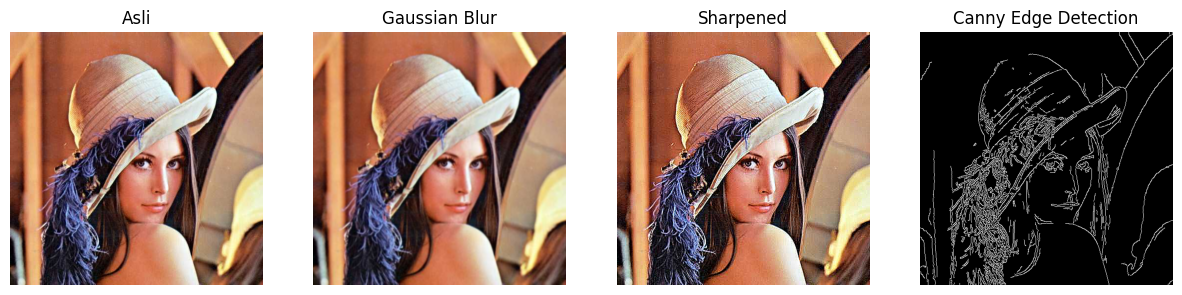

In [14]:
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:      # grayscale
            plt.subplot(1, len(images), i + 1)
            plt.imshow(img, cmap="gray")
        else:                        # color
            plt.subplot(1, len(images), i + 1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img = cv.imread("lena.jpg") if os.path.exists("lena.jpg") else lena
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7, 7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)

show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

## Percobaan 2 — Filter Modern: Bilateral Filter & Edge Preserving (Guided Filter)

**Bilateral filter** menghaluskan citra namun mempertahankan tepi dengan mempertimbangkan jarak spasial **dan** kemiripan warna.
**Guided / Edge Preserving filter** memberi hasil mirip bilateral tetapi jauh lebih cepat dan halus.

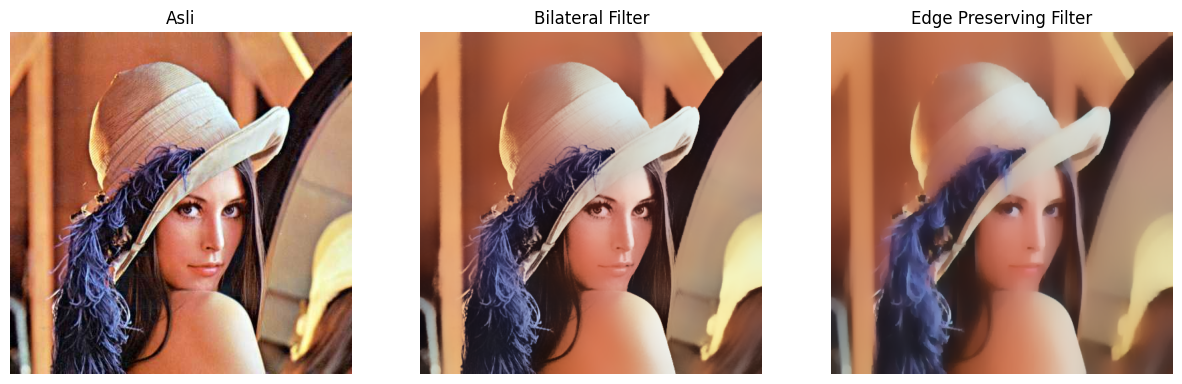

In [15]:
bilateral = cv.bilateralFilter(img, 50, 100, 100)

edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

## Percobaan 3 — Filtering pada CNN (Feature Map)

Jalankan sel berkali-kali dan perhatikan outputnya.
**Kesimpulan:** bobot `Conv2d` diinisialisasi **acak**, jadi tiap kali dijalankan filter (feature map) yang dihasilkan berbeda. Setiap filter belajar menangkap pola berbeda (tepi, tekstur, gradien arah tertentu).

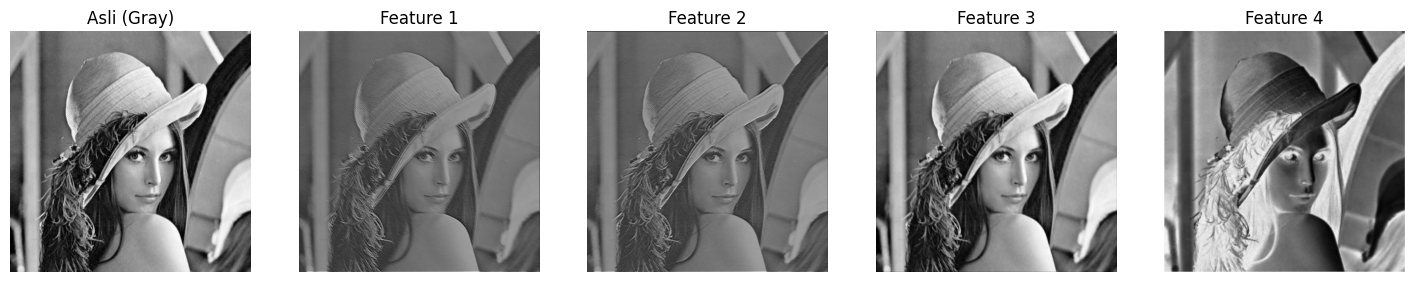

In [16]:
try:
    import torch
    import torch.nn as nn

    class SimpleCNN(nn.Module):
        def __init__(self):
            super(SimpleCNN, self).__init__()
            self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

        def forward(self, x):
            return self.conv1(x)

    model = SimpleCNN()

    img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

    with torch.no_grad():
        features = model(img_tensor)

    feature_maps = [features[0, i].numpy() for i in range(features.shape[1])]
    show_side_by_side([img_gray] + feature_maps,
                      ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))],
                      figsize=(18, 4))
except ImportError:
    print("PyTorch tidak terpasang. Di Colab jalankan: !pip install torch")

## Percobaan 4 — Beauty Filter & Old/Vintage Filter

Kombinasi beberapa filter tradisional: smoothing (bilateral), unsharp masking, brightness/contrast, sepia, vignette, dan grain.

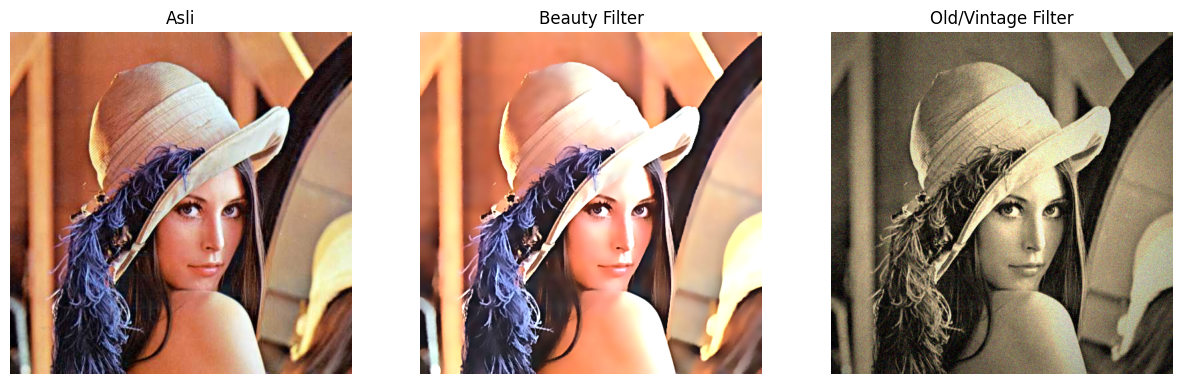

In [17]:
# 1. Beauty Filter
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0, 0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2   # contrast
beta = 15     # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# 2. Old/Vintage Filter
# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols * 0.6)
kernel_y = cv.getGaussianKernel(rows, rows * 0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:, :, i] = vignette[:, :, i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img, beauty, old_img],
                  ["Asli", "Beauty Filter", "Old/Vintage Filter"])

## Percobaan 5 — Filter Anime / Cartoon

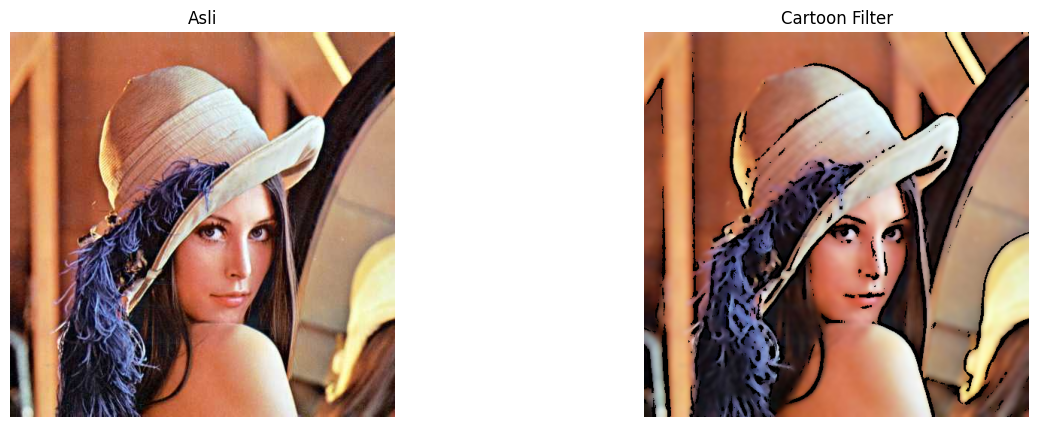

In [18]:
# Step 1: Edge detection (pakai median blur dulu agar gambar lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

## Percobaan 6 — Filter Malam (Night Filter)

Memakai citra pemandangan (`djawatan.jpg`).

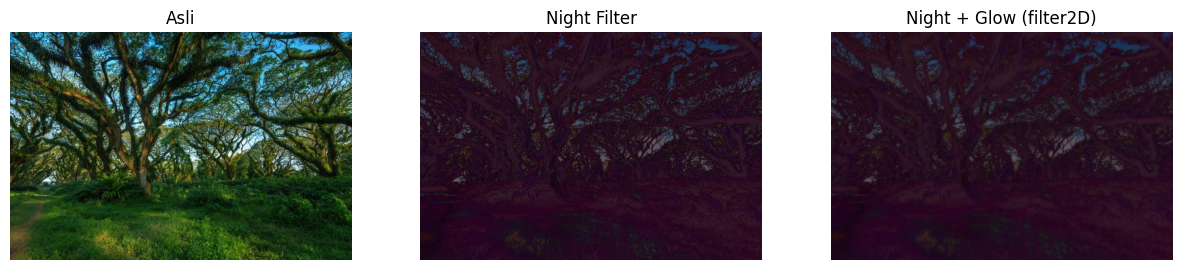

In [19]:
img_night = scene.copy()
img_gray = cv.cvtColor(img_night, cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img_night, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15, 15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img_night, night, night_glow],
                  ["Asli", "Night Filter", "Night + Glow (filter2D)"],
                  figsize=(15, 4))

## Percobaan 7 — Filter Pagi & Filter Pagi + Kabut

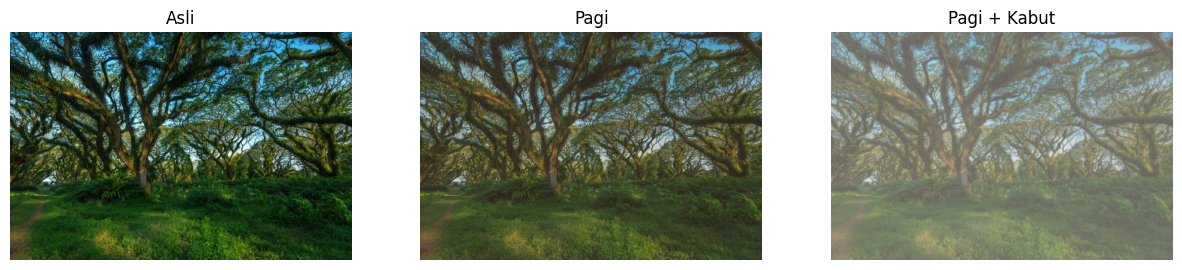

In [20]:
# Step 1: Kurangi kontras & cerahkan
alpha = 0.9   # contrast
beta = 20     # brightness
soft = cv.convertScaleAbs(scene, alpha=alpha, beta=beta)

# Step 2: Tambahkan warm tone (kemerahan / oranye)
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T   # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([scene, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"],
                  figsize=(15, 4))

---
# TUGAS PRAKTIKUM

## Tugas 1, Analisis: Mean Filter vs Median Filter pada Noise "Salt and Pepper"

1. Tambahkan noise bintik hitam-putih (Salt and Pepper) ke citra keabuan.
2. Terapkan Mean Filter (3x3) dan Median Filter (3x3).
3. Amati mengapa Median Filter jauh lebih bersih.

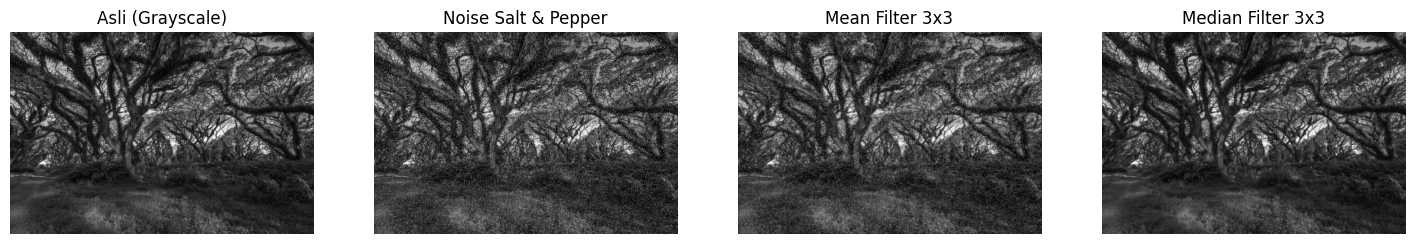

In [21]:
def add_salt_pepper(img, amount=0.05):
    """Tambahkan noise salt (putih) & pepper (hitam) sebanyak `amount` dari total piksel."""
    out = img.copy()
    H, W = img.shape[:2]
    n = int(amount * H * W)
    # Salt (putih)
    ys = np.random.randint(0, H, n)
    xs = np.random.randint(0, W, n)
    out[ys, xs] = 255
    # Pepper (hitam)
    ys = np.random.randint(0, H, n)
    xs = np.random.randint(0, W, n)
    out[ys, xs] = 0
    return out

def mean_filter(img, k=3):
    """Mean filter manual memakai convolution2d."""
    kernel = np.ones((k, k), dtype=np.float64) / (k * k)
    return to_uint8(convolution2d(img, kernel, stride=1, padding=k // 2))

def median_filter(img, k=3):
    """Median filter manual memakai sliding window (tanpa cv2.medianBlur)."""
    from numpy.lib.stride_tricks import sliding_window_view
    pad = k // 2
    p = np.pad(img, pad, mode="edge")
    windows = sliding_window_view(p, (k, k))
    return np.median(windows, axis=(-1, -2)).astype(np.uint8)

gray_clean = img_gray.copy()
noisy = add_salt_pepper(gray_clean, amount=0.05)
mean_res = mean_filter(noisy, 3)
median_res = median_filter(noisy, 3)

show_side_by_side([gray_clean, noisy, mean_res, median_res],
                  ["Asli (Grayscale)", "Noise Salt & Pepper",
                   "Mean Filter 3x3", "Median Filter 3x3"],
                  figsize=(18, 5))

### Analisis Tugas 1

**Mengapa Median Filter jauh lebih bersih daripada Mean Filter?**

- **Mean filter** mengganti nilai piksel dengan **rata-rata** seluruh piksel di jendela 3x3. Noise salt & pepper bernilai ekstrem (0 dan 255), sehingga nilai ekstrem ini ikut dijumlahkan dan **menyebar** ke piksel-piksel tetangganya. Akibatnya bintik hitam/putih berubah menjadi **bercak kabur (blur)** yang masih terlihat, dan tepi citra ikut melunak.
- **Median filter** mengganti nilai piksel dengan **nilai tengah (median)** setelah diurutkan. Karena noise salt & pepper hanya menempati 1 dari 9 piksel jendela, nilai 0 atau 255 berada di **ujung urutan** dan tidak terpilih sebagai median. Jadi noise ekstrem **dibuang**, sementara piksel normal di sekitarnya tetap dipertahankan.

**Kesimpulan:** Median filter adalah *non-linear filter* yang sangat efektif untuk noise **impulsif** (salt & pepper) sekaligus menjaga ketajaman tepi, sedangkan mean filter (linear) hanya menyebarkan noise tersebut.

## Tugas 2 — Evaluasi: Pemilihan Ukuran Kernel Terbaik untuk Sharpening

1. Buat kernel penajaman 3x3 dan 5x5.
2. Terapkan pada citra yang sedikit buram (blurry).
3. Evaluasi berdasarkan **kejelasan tepi** vs **kadar noise**.

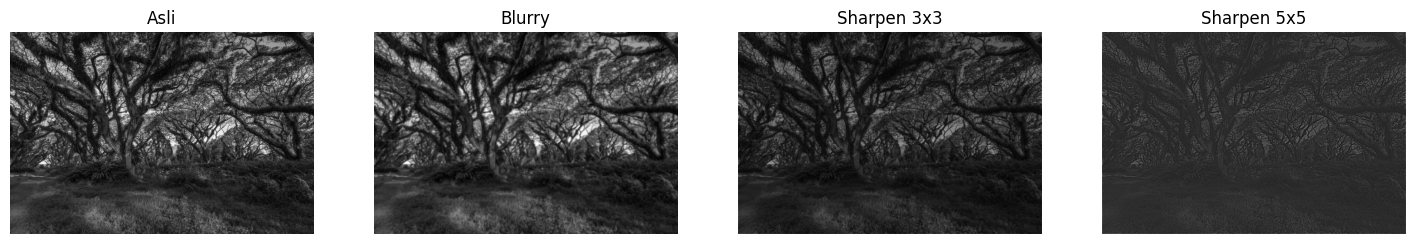

In [22]:
# Citra dibuat sedikit buram terlebih dahulu
blurry = cv.GaussianBlur(img_gray, (5, 5), 1.5)

# Kernel sharpening 3x3
k3 = np.array([[ 0, -1,  0],
               [-1,  5, -1],
               [ 0, -1,  0]], dtype=np.float64)

# Kernel sharpening 5x5
k5 = np.array([[ 0,  0, -1,  0,  0],
               [ 0, -1, -2, -1,  0],
               [-1, -2, 17, -2, -1],
               [ 0, -1, -2, -1,  0],
               [ 0,  0, -1,  0,  0]], dtype=np.float64)

sharp3 = to_uint8(convolution2d(blurry, k3, stride=1, padding=1))
sharp5 = to_uint8(convolution2d(blurry, k5, stride=1, padding=2))

show_side_by_side([img_gray, blurry, sharp3, sharp5],
                  ["Asli", "Blurry", "Sharpen 3x3", "Sharpen 5x5"],
                  figsize=(18, 5))

### Analisis Tugas 2

| Aspek | Kernel 3x3 | Kernel 5x5 |
|---|---|---|
| Kejelasan tepi | Tepi lebih tajam dari asli, tapi tidak seagresif 5x5 | Tepi paling tajam/tegas |
| Kadar noise | Noise relatif rendah, hasil natural | Noise & *halo* (ringing) lebih terlihat, terutama di area rata |

- Kernel 5x5 memperkuat frekuensi tinggi lebih besar (koefisien pusat 17 vs 5), sehingga tepi terlihat lebih tegas **tetapi** sekaligus menguatkan noise dan memunculkan artefak *halo/ringing* di sekitar tepi.
- Kernel 3x3 memberikan keseimbangan terbaik antara ketajaman dan kebersihan citra.

**Rekomendasi untuk pemakaian sehari-hari:** gunakan **kernel 3x3** (atau *unsharp masking*). Ketajamannya sudah cukup, hasilnya natural, dan tidak mudah memunculkan noise. Kernel 5x5 sebaiknya dipakai hanya bila citra memang sangat buram dan noise-nya rendah.

## Tugas 3 — Kreasi: Filter Kartun Sederhana (`kartun(image)`)

Menggabungkan:
- Penghalusan warna dengan **Bilateral Filter**.
- Deteksi garis tepi dengan **Adaptive Thresholding / Canny**.
- Penggabungan keduanya dengan operasi logika/perkalian piksel.

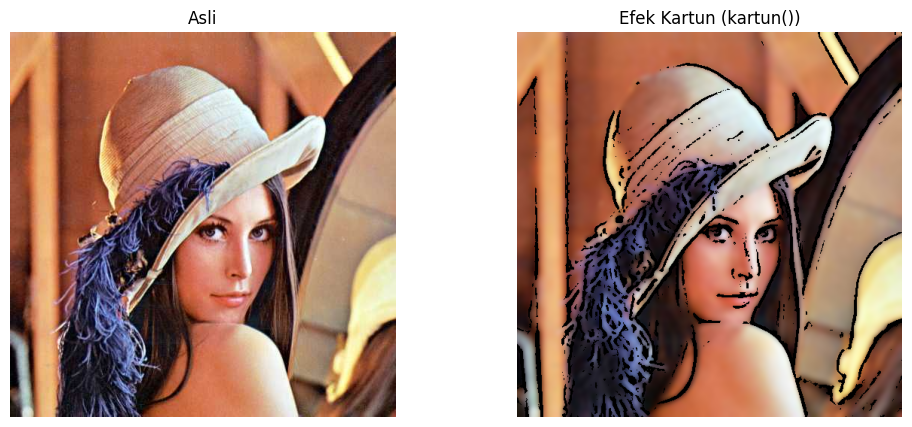

In [23]:
def kartun(image, use_canny=False):
    """Membuat efek kartun dari citra RGB (BGR)."""
    # 1. Haluskan warna agar area warna menjadi rata
    color = cv.bilateralFilter(image, d=9, sigmaColor=250, sigmaSpace=250)
    color = cv.bilateralFilter(color, d=9, sigmaColor=250, sigmaSpace=250)  # 2x agar lebih rata

    # 2. Deteksi garis tepi
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray = cv.medianBlur(gray, 5)
    if use_canny:
        edges = cv.Canny(gray, 80, 180)
    else:
        edges = cv.adaptiveThreshold(gray, 255,
                                     cv.ADAPTIVE_THRESH_MEAN_C,
                                     cv.THRESH_BINARY, 9, 9)
    edges = cv.cvtColor(edges, cv.COLOR_GRAY2BGR)

    # 3. Gabungkan dengan operasi perkalian piksel (bitwise AND)
    hasil = cv.bitwise_and(color, edges)
    return hasil

kartun_hasil = kartun(img, use_canny=False)
show_side_by_side([img, kartun_hasil], ["Asli", "Efek Kartun (kartun())"], figsize=(12, 5))